# 07 — Additional research-paper strategy replications

This notebook adds three paper-inspired strategies that were not in the earlier notebooks:

- low-beta selection;
- constrained sample minimum variance;
- momentum with volatility scaling based on the momentum portfolio's own risk.

The implementations use a small ETF universe, not the original stock-level research datasets. The goal is to understand the signal and test a reproducible adaptation with the same one-day execution delay, monthly rebalancing, and transaction-cost model used across the library.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## Papers and adaptations

- [Betting Against Beta — Frazzini and Pedersen](https://www.nber.org/papers/w16601) predicts that a portfolio long low-beta assets and short high-beta assets can earn positive risk-adjusted returns. Here we test a more conservative long-only adaptation: hold the three ETFs with the lowest trailing beta to SPY. It is not the paper's leveraged long-short BAB factor.
- [Risk Reduction in Large Portfolios: Why Imposing the Wrong Constraints Helps — Jagannathan and Ma](https://www.nber.org/papers/w8922) studies why nonnegative constraints can improve estimated minimum-variance portfolios. Here we estimate a rolling sample covariance matrix, calculate a minimum-variance solution, clip negative weights, and normalize.
- [Momentum Has Its Moments — Barroso and Santa-Clara](https://doi.org/10.1016/j.jfineco.2014.11.010) argues that momentum risk changes over time and that scaling exposure by its own volatility can reduce crashes. Here we apply that idea to the long-only ETF 12-1 momentum portfolio.
- [Momentum Crashes — Daniel and Moskowitz](https://ideas.repec.org/a/eee/jfinec/v122y2016i2p221-247.html) is related evidence that momentum risk depends on market conditions. This notebook does not claim to reproduce their conditional stock-level strategy.
- [Value and Momentum Everywhere — Asness, Moskowitz, and Pedersen](https://w4.stern.nyu.edu/facdir/lpederse/papers/ValMomEverywhere.pdf) remains an important factor paper, but value is deliberately not fabricated here because current ETF valuation fields are not point-in-time fundamentals.

## Beginner guide: what the signals mean

**Beta** measures how much an asset has historically moved with the market. A beta of 1.2 means the asset tended to move about 1.2% when the market moved 1%, though this relationship changes. We calculate beta only from completed historical returns and rank assets monthly.

**Minimum variance** does not predict returns. It uses the recent covariance matrix to choose weights whose estimated portfolio variance is low. Covariance is noisy, so the result can be unstable; the nonnegative constraint and small ridge are deliberate safeguards.

**Volatility-scaled momentum** first selects 12-month winners while skipping the most recent month. It then reduces the portfolio's total exposure when the momentum portfolio itself has high trailing volatility. Any unallocated exposure is treated as cash by this simple backtester.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    cross_sectional_momentum_weights,
    equal_weight_weights,
    inverse_volatility_weights,
    low_beta_weights,
    low_volatility_weights,
    minimum_variance_weights,
    momentum_volatility_scaled_weights,
    run_portfolio_backtest,
)
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data and assumptions

We use SPY, QQQ, IWM, EFA, EEM, TLT, and GLD with adjusted daily closes from 2010 through 2025. The first 60–252 observations are warm-up periods for the indicators. Strategies rebalance monthly and target weights are delayed one trading day before returns are applied. Costs are 10 basis points per unit of absolute weight change. The last 20% of observations is the formal test period.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD']

if USE_DEMO_DATA:
    close = pd.concat(
        [make_demo_ohlcv(periods=4_000, seed=i + 1, start='2010-01-01')['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
        axis=1,
    )
else:
    try:
        close = load_price_panel(TICKERS, '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat(
            [make_demo_ohlcv(periods=4_000, seed=i + 1, start='2010-01-01')['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
            axis=1,
        )

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2010-01-04 through 2025-12-31 (4,024 common trading days)
{'train': (datetime.date(2010, 1, 4), datetime.date(2019, 8, 6), 2414), 'validation': (datetime.date(2019, 8, 7), datetime.date(2022, 10, 14), 805), 'test': (datetime.date(2022, 10, 17), datetime.date(2025, 12, 31), 805)}


In [3]:
weights = {
    'Equal-weight control': equal_weight_weights(close),
    'Low-volatility selection': low_volatility_weights(close, lookback=60, top_n=3),
    'Inverse-volatility risk parity': inverse_volatility_weights(close, lookback=60),
    'Low-beta selection': low_beta_weights(close, lookback=252, top_n=3, market_asset='SPY'),
    'Minimum variance': minimum_variance_weights(close, lookback=60),
    '12-1 momentum': cross_sectional_momentum_weights(
        close, lookback=252, skip_recent=21, top_n=3
    ),
    'Volatility-scaled 12-1 momentum': momentum_volatility_scaled_weights(
        close, momentum_lookback=252, skip_recent=21, top_n=3,
        volatility_lookback=126, target_volatility=0.12
    ),
}

results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}
print('Paper-inspired strategies are ready. Parameters were declared before reading the formal test results.')

Paper-inspired strategies are ready. Parameters were declared before reading the formal test results.


## 📈 Formal test-period comparison

The most important comparison is not “which Sharpe is largest?” It is whether an apparent improvement remains visible after costs, a clean chronological split, and a reasonable drawdown. A high Sharpe can be caused by a short sample, low exposure, or repeated experimentation.

In [4]:
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Equal-weight control,21.28%,12.83%,1.57,2.45,-12.76%,1.67,56.27%,0.00,0,85.23%,99.27%,-14.04%
Low-volatility selection,22.73%,11.22%,1.88,2.96,-8.42%,2.70,55.90%,3.97,18,92.35%,99.27%,-6.92%
Inverse-volatility risk parity,20.91%,12.21%,1.62,2.53,-11.55%,1.81,55.78%,0.89,38,83.41%,99.27%,-15.86%
Low-beta selection,18.34%,11.23%,1.56,2.38,-12.13%,1.51,55.28%,0.63,3,71.22%,99.27%,-28.05%
Minimum variance,19.60%,12.36%,1.51,2.33,-13.07%,1.50,54.78%,3.20,38,77.16%,99.27%,-22.12%
12-1 momentum,23.53%,14.35%,1.54,2.38,-13.80%,1.71,57.14%,4.38,19,96.43%,99.27%,-2.85%
Volatility-scaled 12-1 momentum,17.81%,12.31%,1.39,2.11,-12.37%,1.44,57.14%,3.83,34,68.81%,99.27%,-30.46%


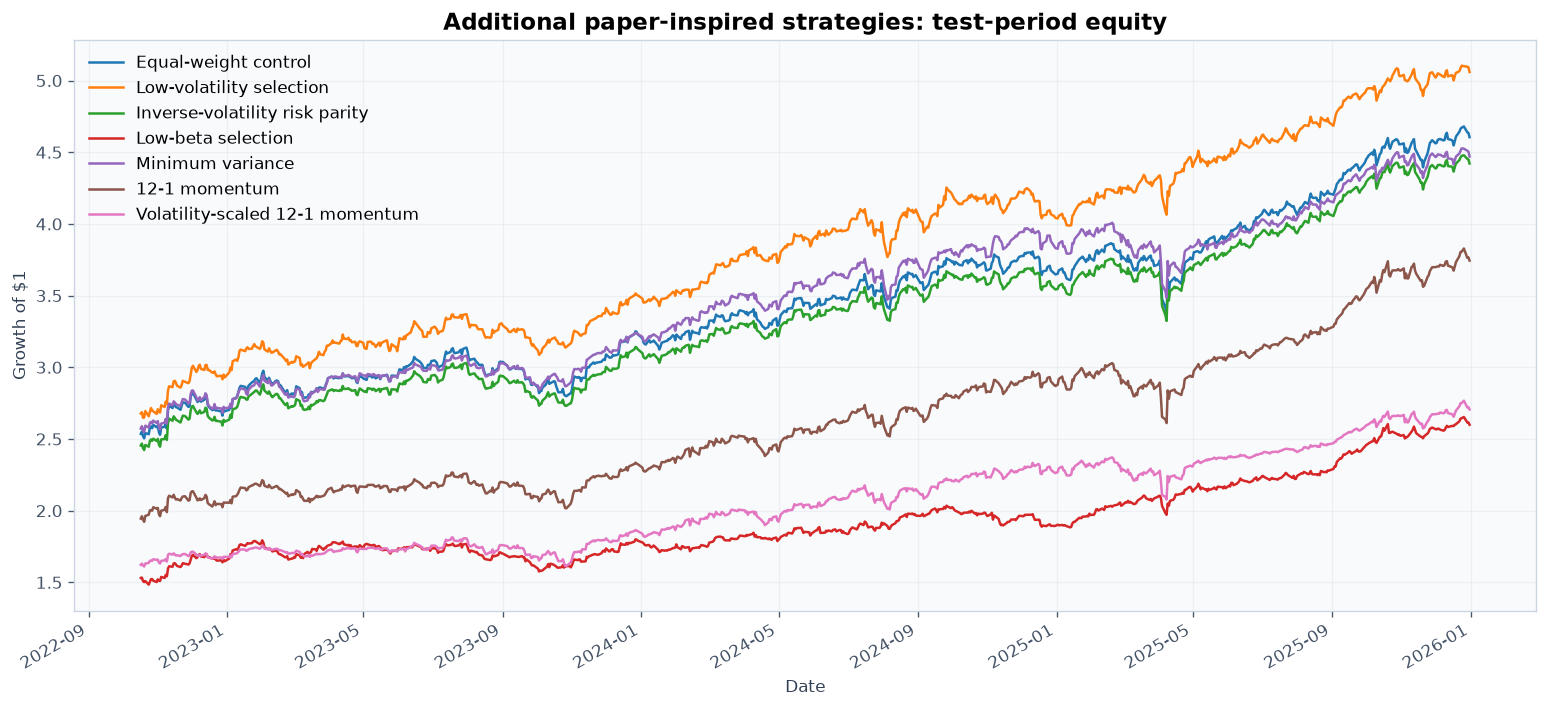

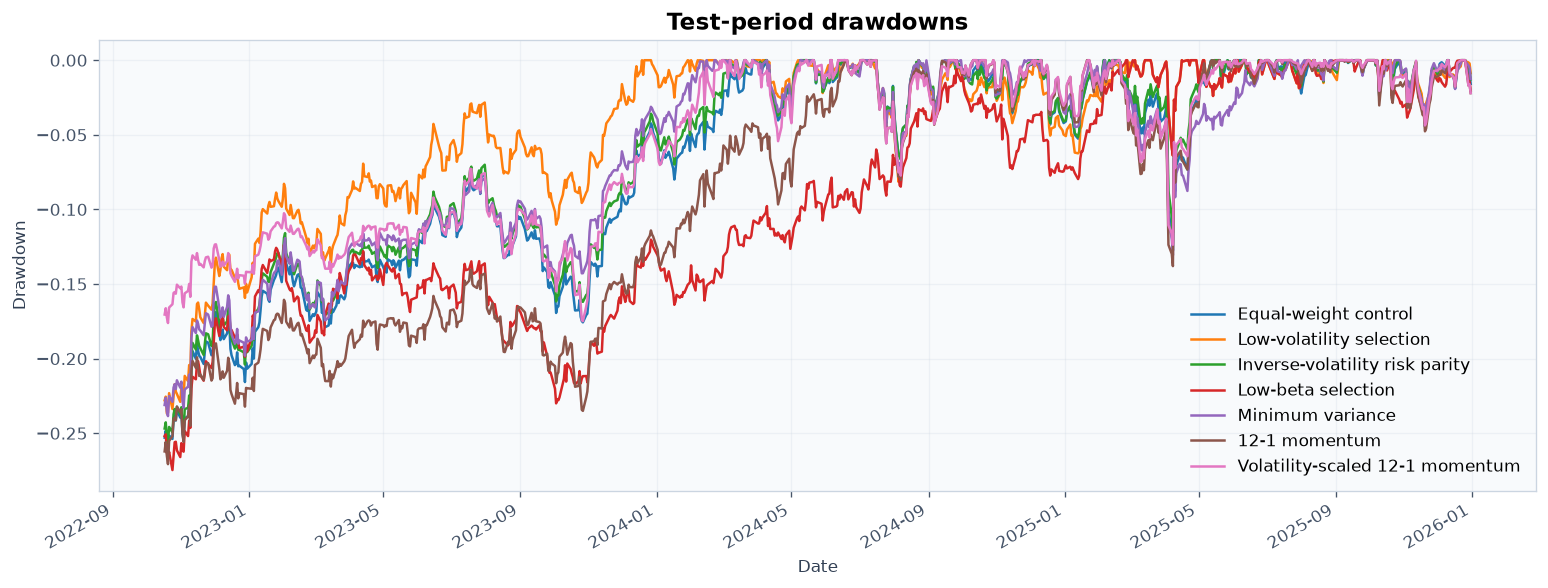

In [5]:
ax = None
for name, result in results.items():
    normalized = result.frame['equity'] / result.frame['equity'].iloc[0]
    ax = normalized.loc[splits['test'].index].plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Additional paper-inspired strategies: test-period equity')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

pd.DataFrame({name: result.frame['drawdown'] for name, result in results.items()}).loc[
    splits['test'].index
].plot(figsize=(13, 5), title='Test-period drawdowns')
plt.ylabel('Drawdown')
plt.grid(alpha=0.25)
plt.show()

## Cost sensitivity

Low-beta and minimum-variance portfolios can look quiet, while momentum can trade more when the selected winners change. The same cost model is applied to every strategy so we can see whether the ranking is fragile.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    for name, target_weights in weights.items():
        cost_result = run_portfolio_backtest(
            close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns
        )
        metrics = metrics_for_period(cost_result, splits['test'].index)
        cost_rows.append({
            'strategy': name,
            'cost_bps': cost_bps,
            'test_return': metrics['total_return_after_costs'],
            'test_sharpe': metrics['sharpe_ratio'],
            'annualized_turnover': metrics['annualized_turnover'],
        })

cost_table = pd.DataFrame(cost_rows)
cost_table.style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'annualized_turnover': '{:.2f}',
})

,strategy,cost_bps,test_return,test_sharpe,annualized_turnover
0,Equal-weight control,0,85.23%,1.57,0.00
1,Low-volatility selection,0,94.81%,1.92,3.97
2,Inverse-volatility risk parity,0,83.93%,1.62,0.89
3,Low-beta selection,0,71.57%,1.56,0.63
4,Minimum variance,0,78.97%,1.54,3.20
5,12-1 momentum,0,99.19%,1.58,4.38
6,Volatility-scaled 12-1 momentum,0,70.89%,1.42,3.83
7,Equal-weight control,5,85.23%,1.57,0.00
8,Low-volatility selection,5,93.58%,1.90,3.97
9,Inverse-volatility risk parity,5,83.67%,1.62,0.89


## Validation sweeps

These are small, declared grids. We rank variants using the validation period and show the formal test only as a later diagnostic. Choosing the best-looking test result after seeing it would overfit the test set.

In [7]:
sweep_rows = []

for lookback in [126, 252, 378]:
    candidate_weights = low_beta_weights(close, lookback=lookback, top_n=3, market_asset='SPY')
    candidate_result = run_portfolio_backtest(
        close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    validation = metrics_for_period(candidate_result, splits['validation'].index)
    test = metrics_for_period(candidate_result, splits['test'].index)
    sweep_rows.append({
        'family': 'low beta',
        'parameter': f'lookback={lookback}',
        'validation_sharpe': validation['sharpe_ratio'],
        'test_sharpe_diagnostic': test['sharpe_ratio'],
        'test_return_diagnostic': test['total_return_after_costs'],
    })

for lookback in [40, 60, 120]:
    candidate_weights = minimum_variance_weights(close, lookback=lookback)
    candidate_result = run_portfolio_backtest(
        close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    validation = metrics_for_period(candidate_result, splits['validation'].index)
    test = metrics_for_period(candidate_result, splits['test'].index)
    sweep_rows.append({
        'family': 'minimum variance',
        'parameter': f'lookback={lookback}',
        'validation_sharpe': validation['sharpe_ratio'],
        'test_sharpe_diagnostic': test['sharpe_ratio'],
        'test_return_diagnostic': test['total_return_after_costs'],
    })

for target_volatility in [0.08, 0.12, 0.16]:
    candidate_weights = momentum_volatility_scaled_weights(
        close, momentum_lookback=252, skip_recent=21, top_n=3,
        volatility_lookback=126, target_volatility=target_volatility
    )
    candidate_result = run_portfolio_backtest(
        close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    validation = metrics_for_period(candidate_result, splits['validation'].index)
    test = metrics_for_period(candidate_result, splits['test'].index)
    sweep_rows.append({
        'family': 'risk-managed momentum',
        'parameter': f'target_vol={target_volatility:.0%}',
        'validation_sharpe': validation['sharpe_ratio'],
        'test_sharpe_diagnostic': test['sharpe_ratio'],
        'test_return_diagnostic': test['total_return_after_costs'],
    })

validation_sweep = pd.DataFrame(sweep_rows).sort_values(
    ['family', 'validation_sharpe'], ascending=[True, False]
)
validation_sweep.style.format({
    'validation_sharpe': '{:.2f}',
    'test_sharpe_diagnostic': '{:.2f}',
    'test_return_diagnostic': '{:.2%}',
})

,family,parameter,validation_sharpe,test_sharpe_diagnostic,test_return_diagnostic
2,low beta,lookback=378,-0.08,1.59,73.51%
0,low beta,lookback=126,-0.09,1.59,73.48%
1,low beta,lookback=252,-0.11,1.56,71.22%
3,minimum variance,lookback=40,0.15,1.53,78.56%
5,minimum variance,lookback=120,0.14,1.58,84.25%
4,minimum variance,lookback=60,0.14,1.51,77.16%
6,risk-managed momentum,target_vol=8%,0.11,1.36,42.24%
7,risk-managed momentum,target_vol=12%,0.09,1.39,68.81%
8,risk-managed momentum,target_vol=16%,0.08,1.47,84.61%


## What we learned

- Low-beta selection is not the same as low volatility: beta measures co-movement with SPY, while volatility measures an asset's own total variation.
- Minimum variance is an estimation problem. A very concentrated portfolio may be a sign of noisy covariance estimates, not superior research.
- Momentum volatility scaling can reduce drawdown while also lowering exposure and raw return. Report the exposure path, not only the Sharpe ratio.
- These are ETF adaptations. The original papers use broader stock universes, different portfolio formation rules, and more detailed data.
- No value strategy is added here because a current valuation multiple would not be a point-in-time historical signal.

Before accepting any apparent high-Sharpe result, rerun it with different universes, dates, costs, and data vendors. The repository should preserve the failed variants too.

## ⚖️ What went well / what went wrong

**What went well:** Low-volatility selection remained the strongest risk-adjusted strategy in the current live test, while low beta and minimum variance offered understandable defensive alternatives. The notebook makes the covariance, beta, nonnegative-weight, and volatility-scaling assumptions visible.

**What went wrong:** Low beta and minimum variance lagged SPY's raw return in this sample. Volatility-scaled 12–1 momentum reduced exposure but also reduced return and Sharpe, so scaling did not automatically improve the result. Rolling beta and covariance estimates are noisy and can create concentrated or unstable weights.

The important lesson is to separate a good risk-control result from a good return result; they are not interchangeable.